#The effect of parents on student's grades
This notebook conducts data analytics to determine how parents and family dynamics can affect a student's grades.

##Importing Libraries and Loading Files

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_studentmat = pd.read_csv('student-mat.csv',sep=';')
df_studentpor = pd.read_csv('student-por.csv',sep=';')

#Preliminary analysis (EDA)

There are no null values in the both the Mathematics and Portuguese datasets. Both datasets have the same columns.

The two datasets were not merged together to explore if there any differences in how Mathematics grades and Portuguese grades correlated with family relationships.

In [ ]:
df_studentmat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df_studentpor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [ ]:
df_studentmat.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
df_studentpor.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
df_studentpor.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
df_studentmat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
#creating a concatenated dataframe
df_combined = pd.concat([df_studentmat, df_studentpor], ignore_index=True)

In [ ]:
df_studentmat.shape

(395, 33)

In [ ]:
df_studentpor.shape

(649, 33)

In [ ]:
df_combined.shape

(1044, 33)

#Heatmap to find correlation between grades and other factors


Correlation with Final Grade (G3):
G3            1.000000
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


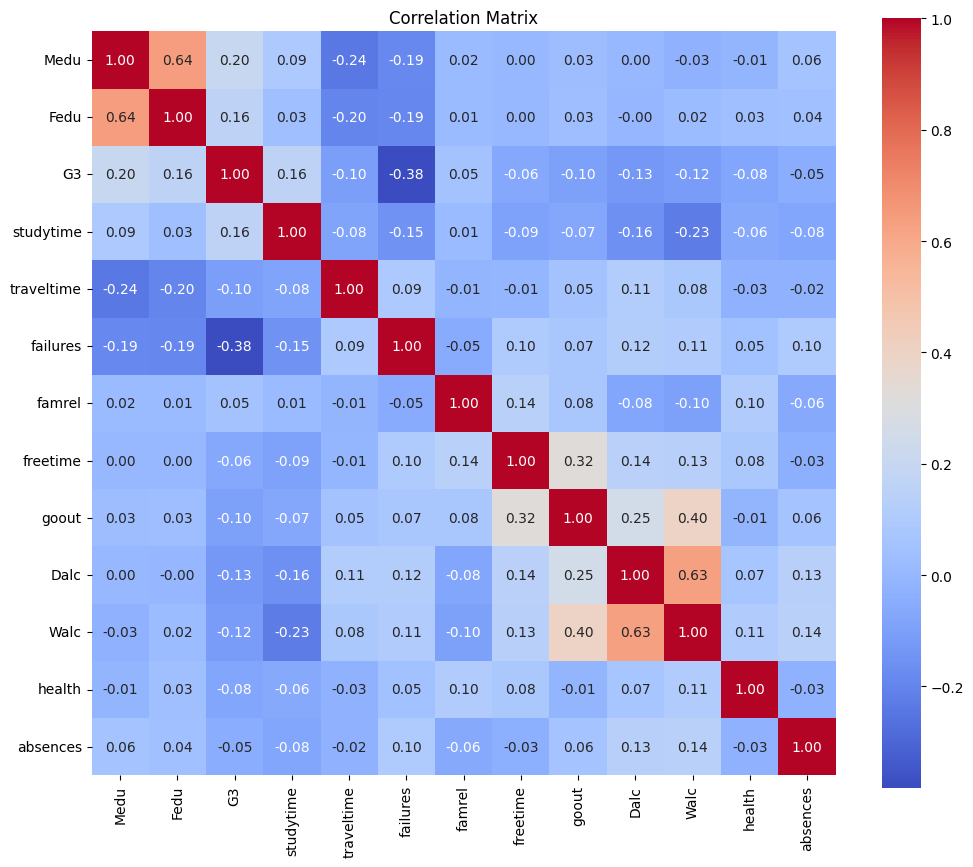

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
numeric_columns = ['Medu', 'Fedu', 'G3', 'studytime', 'traveltime', 'failures',
                   'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
df_combined[numeric_columns] = df_combined[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Drop rows with any NaN values
df_combined.dropna(inplace=True)

# Calculate the correlation matrix (only numeric columns)
correlation_matrix = df_combined[numeric_columns].corr()

# Focus on the correlation with the final grade (G3)
correlation_with_g3 = correlation_matrix['G3'].sort_values(ascending=False)
print("\nCorrelation with Final Grade (G3):")
print(correlation_with_g3)

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

#Relationship between Family Dynamics and Final Grades

##Final Grades by Family Size
Students with larger family seem to get around 1 point lower on average.

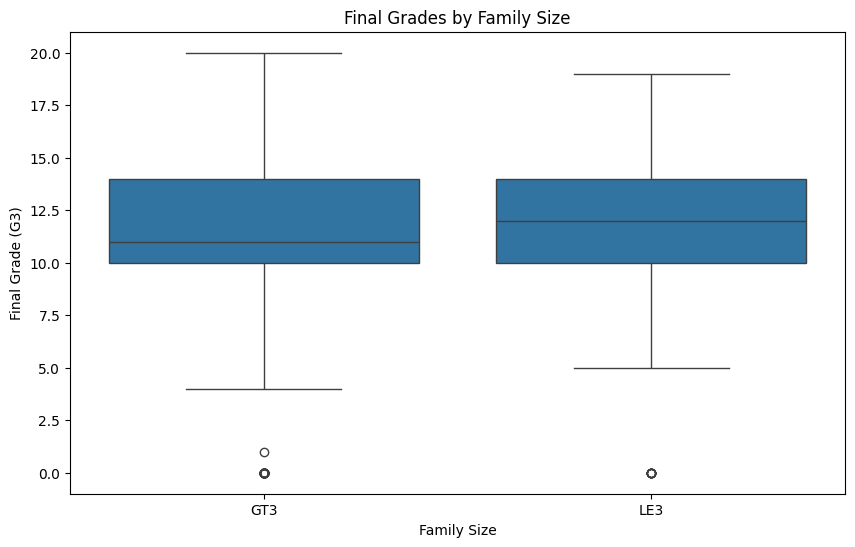

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='famsize', y='G3')
plt.title('Final Grades by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Final Grade (G3)')
plt.show()

##Final Grades by Parents' education
On average, student whose parents are better educated get better grades.

However, there is a small sample of 5 student who each have a parent with no education. These 5 students, on average, get higher grades than the rest of the sample.

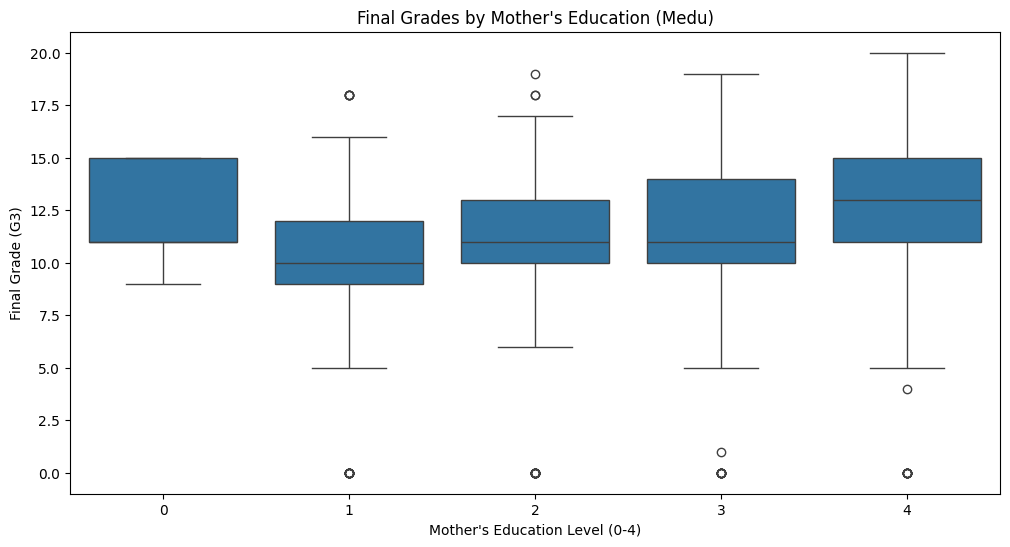

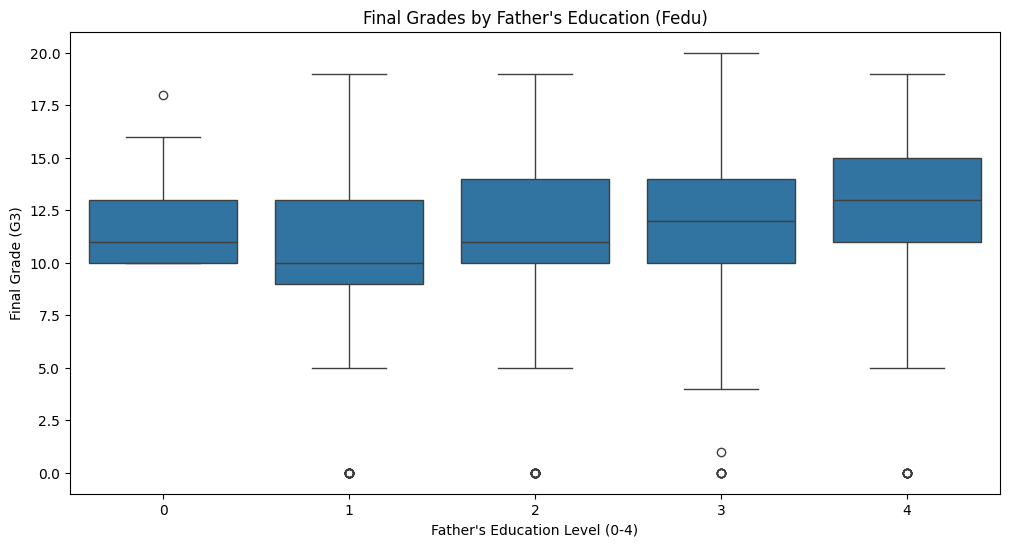

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_combined['G3'] = pd.to_numeric(df_combined['G3'], errors='coerce')
df_combined['Medu'] = pd.to_numeric(df_combined['Medu'], errors='coerce')
df_combined['Fedu'] = pd.to_numeric(df_combined['Fedu'], errors='coerce')

# Drop rows with any NaN values
df_combined.dropna(subset=['G3', 'Medu', 'Fedu'], inplace=True)

# Box plot for mother's education (Medu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x='Medu', y='G3')
plt.title('Final Grades by Mother\'s Education (Medu)')
plt.xlabel('Mother\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

# Box plot for father's education (Fedu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x='Fedu', y='G3')
plt.title('Final Grades by Father\'s Education (Fedu)')
plt.xlabel('Father\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()


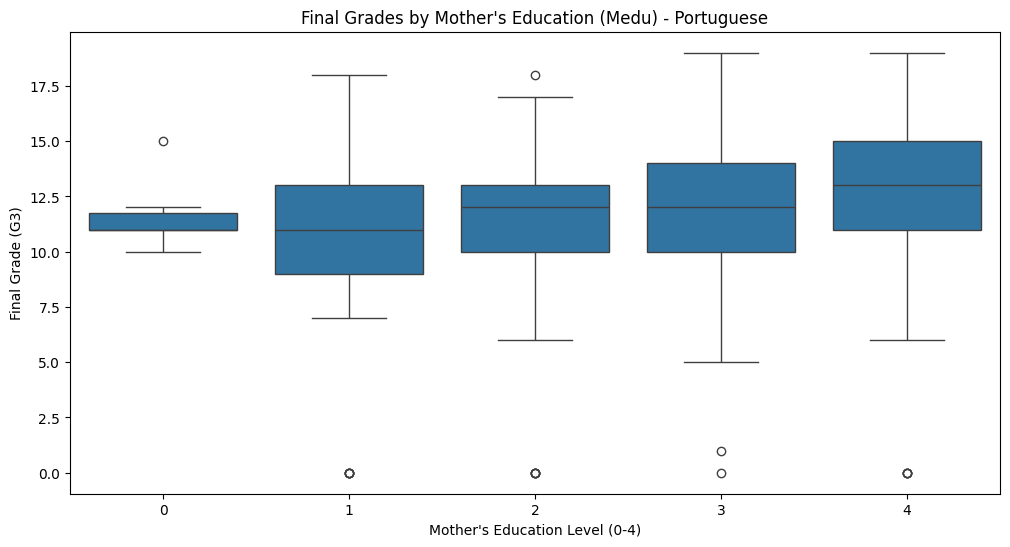

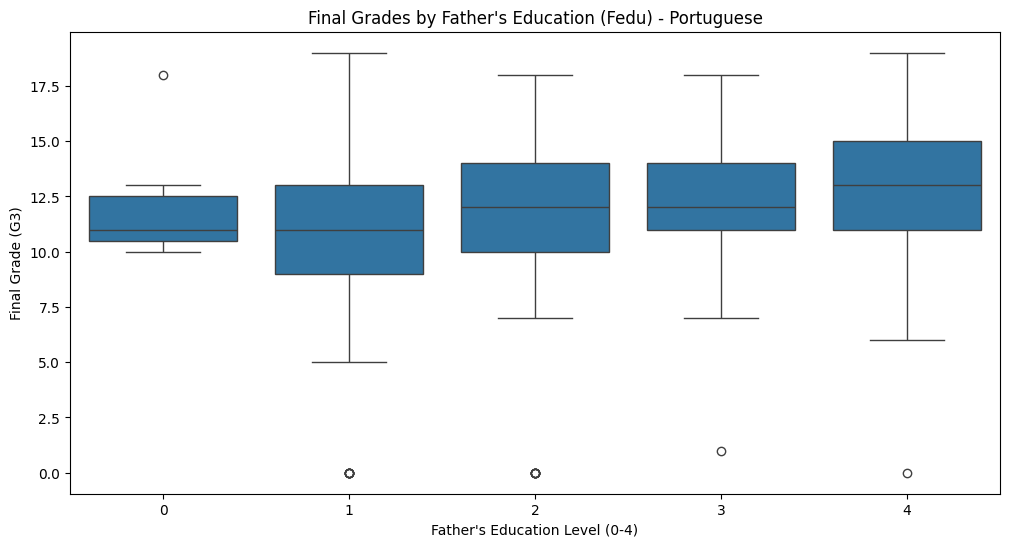

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_studentpor['G3'] = pd.to_numeric(df_studentpor['G3'], errors='coerce')
df_studentpor['Medu'] = pd.to_numeric(df_studentpor['Medu'], errors='coerce')
df_studentpor['Fedu'] = pd.to_numeric(df_studentpor['Fedu'], errors='coerce')

# Drop rows with any NaN values
df_studentpor.dropna(subset=['G3', 'Medu', 'Fedu'], inplace=True)

# Box plot for mother's education (Medu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_studentpor, x='Medu', y='G3')
plt.title('Final Grades by Mother\'s Education (Medu) - Portuguese')
plt.xlabel('Mother\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

# Box plot for father's education (Fedu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_studentpor, x='Fedu', y='G3')
plt.title('Final Grades by Father\'s Education (Fedu) - Portuguese')
plt.xlabel('Father\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()


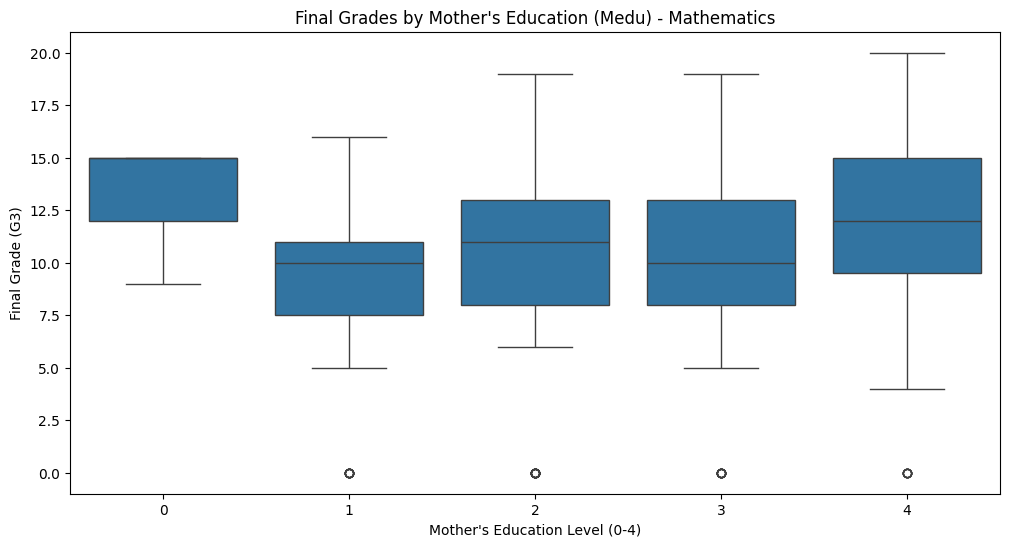

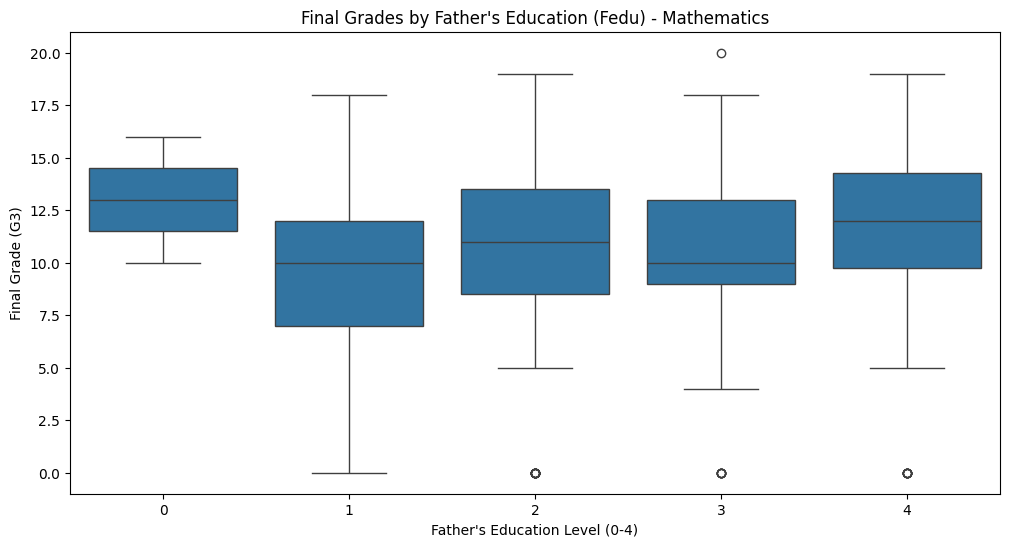

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_studentmat['G3'] = pd.to_numeric(df_studentmat['G3'], errors='coerce')
df_studentmat['Medu'] = pd.to_numeric(df_studentmat['Medu'], errors='coerce')
df_studentmat['Fedu'] = pd.to_numeric(df_studentmat['Fedu'], errors='coerce')

# Drop rows with any NaN values
df_studentmat.dropna(subset=['G3', 'Medu', 'Fedu'], inplace=True)

# Box plot for mother's education (Medu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_studentmat, x='Medu', y='G3')
plt.title('Final Grades by Mother\'s Education (Medu) - Mathematics')
plt.xlabel('Mother\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

# Box plot for father's education (Fedu) vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_studentmat, x='Fedu', y='G3')
plt.title('Final Grades by Father\'s Education (Fedu) - Mathematics')
plt.xlabel('Father\'s Education Level (0-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()


##Final Grades by Parents' job

Students whoses mothers work in the health sector and fathers are teachers get higher grades, on average, than the rest.

The difference is only roughly 1 point.

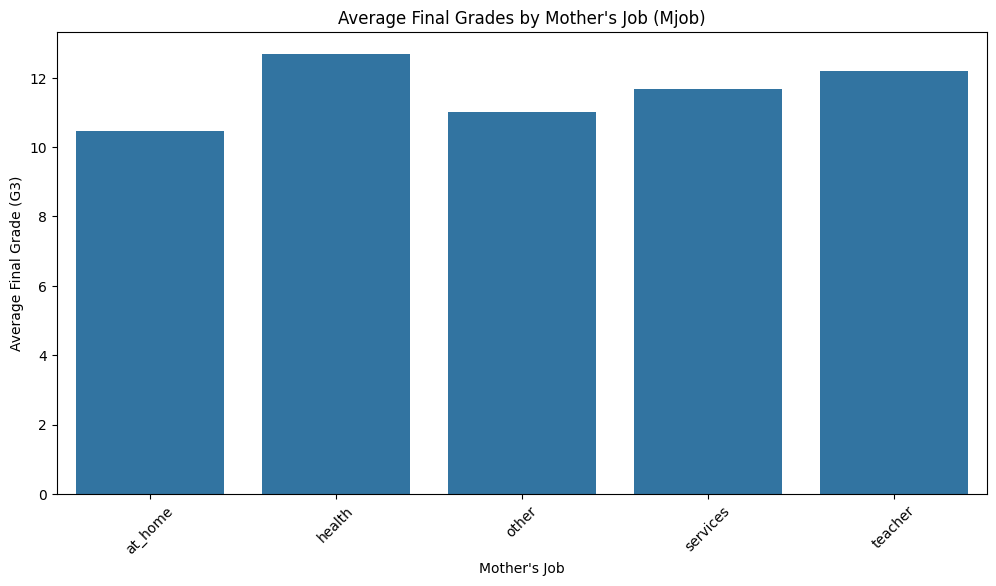

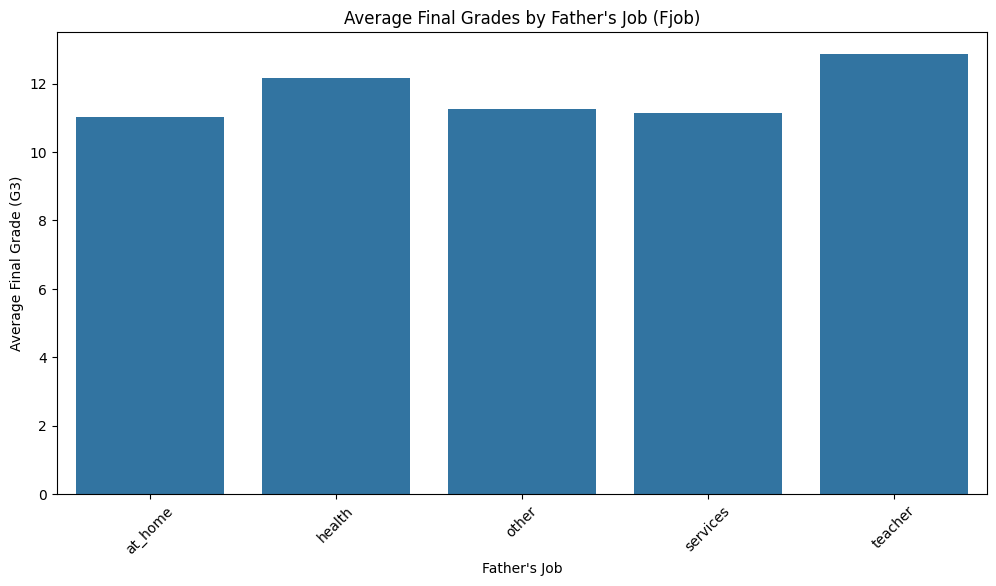

In [ ]:
# Calculate average final grades by mother's job (Mjob)
avg_grades_mjob = df_combined.groupby('Mjob')['G3'].mean().reset_index()

# Bar chart for mother's job (Mjob) vs average final grades (G3)
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_grades_mjob, x='Mjob', y='G3')
plt.title('Average Final Grades by Mother\'s Job (Mjob)')
plt.xlabel('Mother\'s Job')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=45)
plt.show()

# Calculate average final grades by father's job (Fjob)
avg_grades_fjob = df_combined.groupby('Fjob')['G3'].mean().reset_index()

# Bar chart for father's job (Fjob) vs average final grades (G3)
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_grades_fjob, x='Fjob', y='G3')
plt.title('Average Final Grades by Father\'s Job (Fjob)')
plt.xlabel('Father\'s Job')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=45)
plt.show()

##Final Grades by Family Relationships

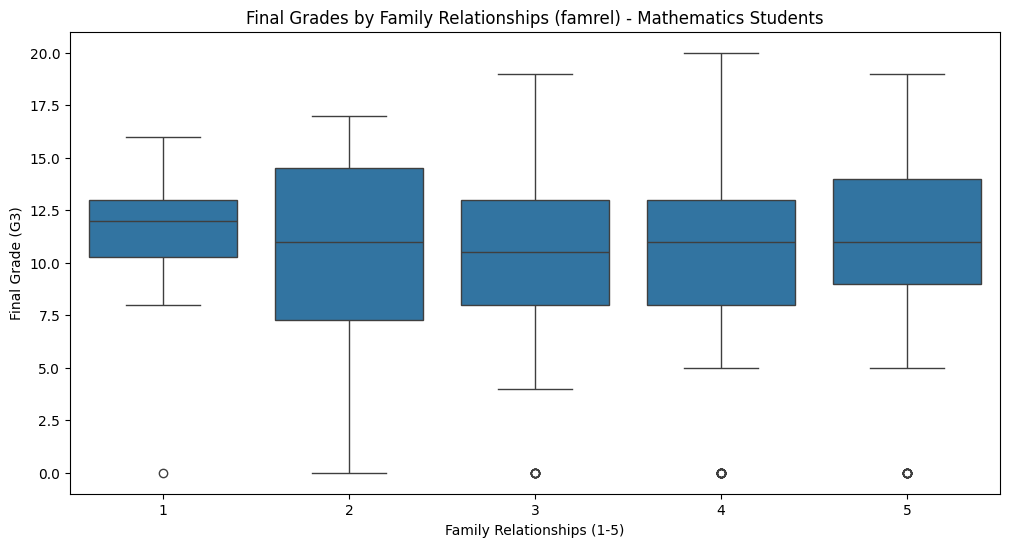

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_studentmat['G3'] = pd.to_numeric(df_studentmat['G3'], errors='coerce')
df_studentmat['famrel'] = pd.to_numeric(df_studentmat['famrel'], errors='coerce')

# Drop rows with any NaN values in G3 or famrel
df_studentmat.dropna(subset=['G3', 'famrel'], inplace=True)

# Box plot for family relationships vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_studentmat, x='famrel', y='G3')
plt.title('Final Grades by Family Relationships (famrel) - Mathematics Students')
plt.xlabel('Family Relationships (1-5)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

##Final Grades by Rural or Urban area

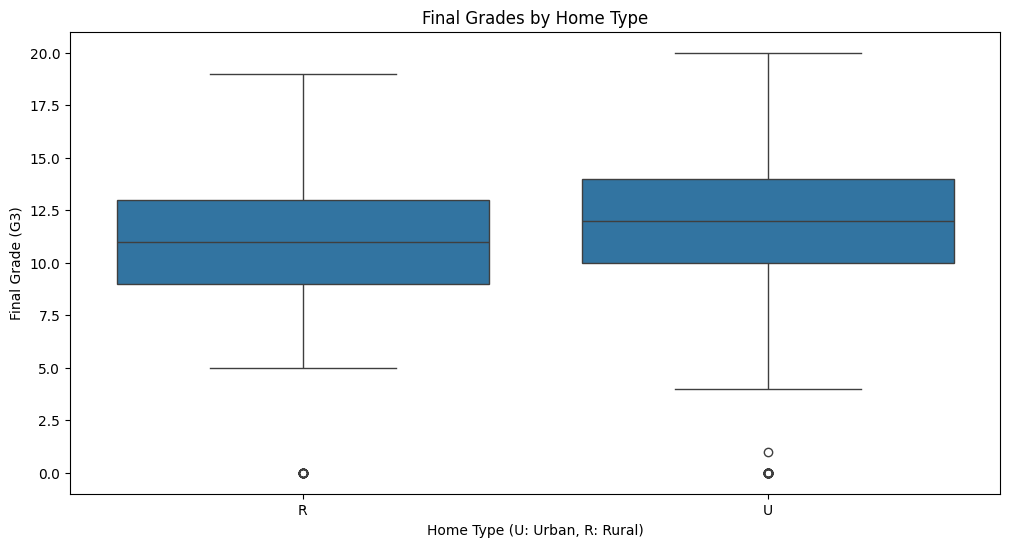

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_combined['G3'] = pd.to_numeric(df_combined['G3'], errors='coerce')
df_combined['address'] = df_combined['address'].astype('category')  # Ensure housing is categorical

# Drop rows with any NaN values in G3
df_combined.dropna(subset=['G3'], inplace=True)

# Box plot for home type vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x='address', y='G3')
plt.title('Final Grades by Home Type')
plt.xlabel('Home Type (U: Urban, R: Rural)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

##Final Grades by Family Educational Support

The presence of educational support from family does not seem to affect final grades.

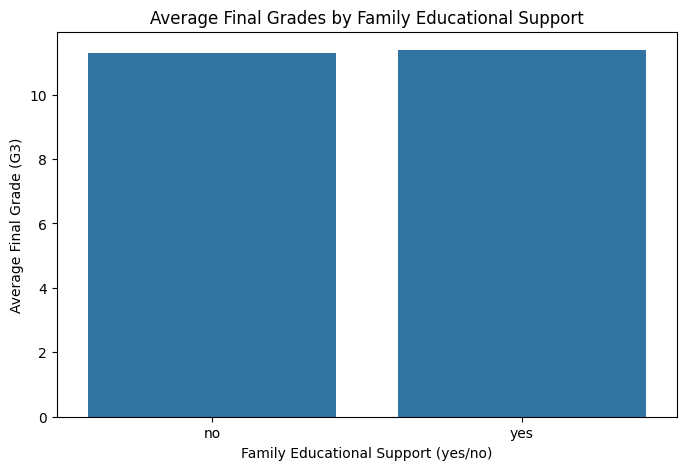

In [ ]:
# Calculate average final grades by family support (famsup)
avg_grades_famsup = df_combined.groupby('famsup')['G3'].mean().reset_index()

# Bar chart for family support vs average final grades (G3)
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_grades_famsup, x='famsup', y='G3')
plt.title('Average Final Grades by Family Educational Support')
plt.xlabel('Family Educational Support (yes/no)')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

##Final Grades by Parental Status

There does not seem to be any relationship between whether the parents are living together and the final grades of the student

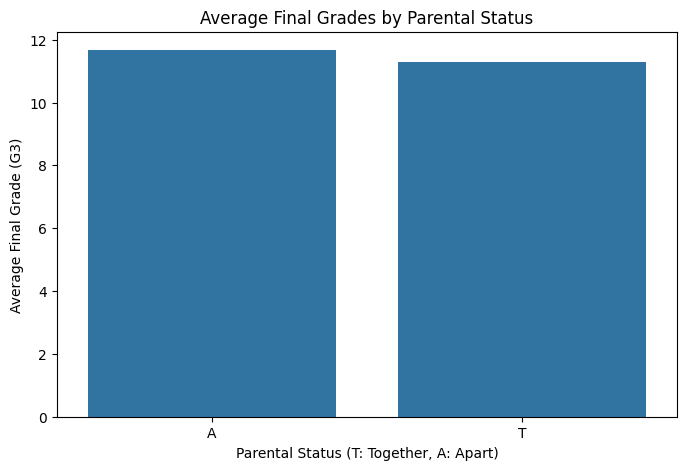

In [ ]:
# Calculate average final grades by parental status (pstatus)
avg_grades_pstatus = df_combined.groupby('Pstatus')['G3'].mean().reset_index()

# Bar chart for parental status vs average final grades (G3)
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_grades_pstatus, x='Pstatus', y='G3')
plt.title('Average Final Grades by Parental Status')
plt.xlabel('Parental Status (T: Together, A: Apart)')
plt.ylabel('Average Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

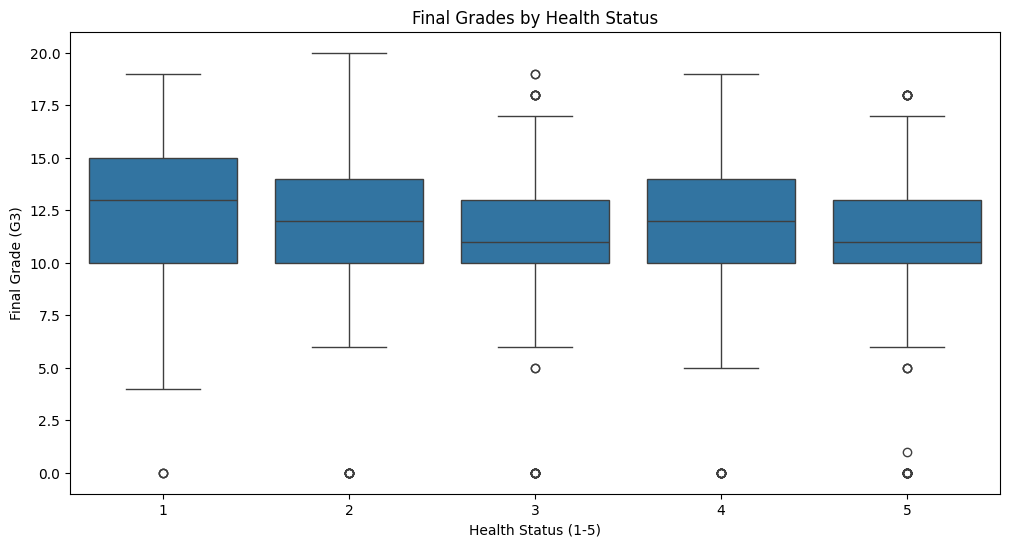

In [ ]:
# Convert relevant columns to numeric, coercing errors to NaN
df_combined['G3'] = pd.to_numeric(df_combined['G3'], errors='coerce')
df_combined['health'] = pd.to_numeric(df_combined['health'], errors='coerce')

# Drop rows with any NaN values in G3 or health
df_combined.dropna(subset=['G3', 'health'], inplace=True)

# Box plot for health vs final grades (G3)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_combined, x='health', y='G3')
plt.title('Final Grades by Health Status')
plt.xlabel('Health Status (1-5)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=0)
plt.show()

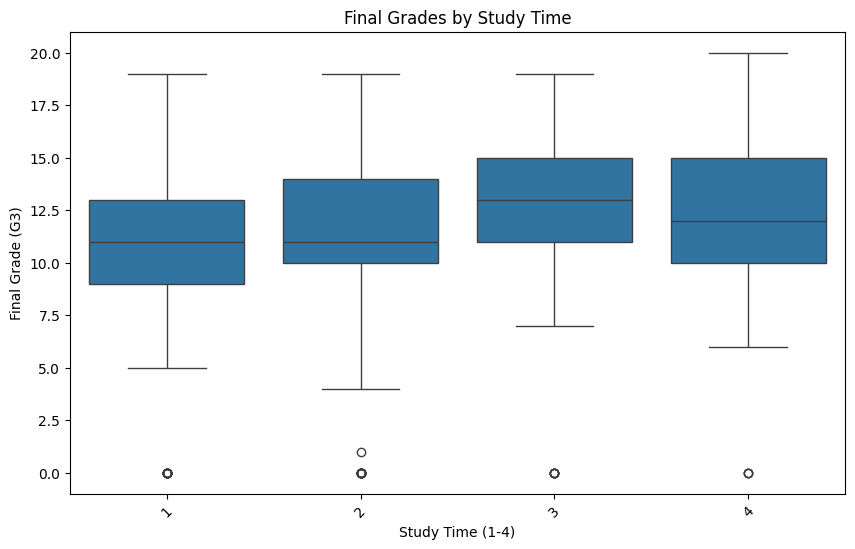

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='studytime', y='G3')
plt.title('Final Grades by Study Time')
plt.xlabel('Study Time (1-4)')
plt.ylabel('Final Grade (G3)')
plt.xticks(rotation=45)
plt.show()

OpenAI. (2023). ChatGPT.